In [3]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import chisquare, ttest_ind
from statsmodels.stats.proportion import proportions_ztest

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")

In [4]:
current_dir = Path.cwd()
project_root = (
    current_dir.parent
    if current_dir.name == "notebooks"
    else current_dir
)

possible_paths = [
    project_root / "data" / "homepage_ab_test.csv",
    project_root / "homepage_ab_test.csv",
    current_dir / "homepage_ab_test.csv",
]

data_path = next(
    (path for path in possible_paths if path.exists()),
    None
)

assert data_path is not None, (
    "CSV not found. Place homepage_ab_test.csv "
    "inside the project's data folder."
)

experiment = pd.read_csv(data_path)

print("File:", data_path)
print("Shape:", experiment.shape)
print("Columns:", experiment.columns.tolist())
print("\nData types:")
print(experiment.dtypes)

experiment.head()

File: d:\desktop\coding\Topfolio\A-B-Testing-Product-Experimentation-Analysis-M1\data\homepage_ab_test.csv
Shape: (50000, 7)
Columns: ['user_id', 'arm', 'signup_date', 'signup_completed', 'revenue_30d', 'device', 'acquisition_source']

Data types:
user_id                   str
arm                       str
signup_date               str
signup_completed        int64
revenue_30d           float64
device                    str
acquisition_source        str
dtype: object


,user_id,arm,signup_date,signup_completed,revenue_30d,device,acquisition_source
0,U00001,control,2024-05-09,1,98.48,mobile,organic
1,U00002,variant,2024-05-04,0,0.00,mobile,organic
2,U00003,variant,2024-05-06,0,0.00,desktop,organic
3,U00004,variant,2024-05-08,0,0.00,mobile,organic
4,U00005,control,2024-05-10,0,0.00,mobile,social


In [5]:
print("Duplicate rows:", experiment.duplicated().sum())

print("\nMissing values:")
print(experiment.isna().sum())

print("\nUnique values:")
for column in experiment.columns:
    if experiment[column].nunique() <= 10:
        print(f"\n{column}:")
        print(experiment[column].value_counts(dropna=False))

Duplicate rows: 0

Missing values:
user_id               0
arm                   0
signup_date           0
signup_completed      0
revenue_30d           0
device                0
acquisition_source    0
dtype: int64

Unique values:

arm:
arm
control    25053
variant    24947
Name: count, dtype: int64

signup_completed:
signup_completed
0    48486
1     1514
Name: count, dtype: int64

device:
device
mobile     25029
desktop    24971
Name: count, dtype: int64

acquisition_source:
acquisition_source
organic        17361
paid_search    14983
social         10080
referral        7576
Name: count, dtype: int64


In [6]:
# Sample Ratio Mismatch (SRM) check

arm_counts = (
    experiment["arm"]
    .value_counts()
    .reindex(["control", "variant"])
)

expected_counts = np.array([len(experiment) / 2] * 2)

srm_result = chisquare(
    f_obs=arm_counts.values,
    f_exp=expected_counts
)

srm_summary = pd.DataFrame({
    "arm": arm_counts.index,
    "observed_users": arm_counts.values,
    "expected_users": expected_counts.astype(int),
    "allocation_pct": arm_counts.values / len(experiment) * 100
})

display(srm_summary.round(2))
print(f"Chi-square statistic: {srm_result.statistic:.4f}")
print(f"P-value: {srm_result.pvalue:.4f}")

if srm_result.pvalue < 0.05:
    print("⚠️ SRM detected — investigate experiment assignment.")
else:
    print("✅ No SRM detected — allocation is consistent with 50/50.")

,arm,observed_users,expected_users,allocation_pct
0,control,25053,25000,50.11
1,variant,24947,25000,49.89


Chi-square statistic: 0.2247
P-value: 0.6355
✅ No SRM detected — allocation is consistent with 50/50.


In [7]:
# Primary metric: Signup Conversion Rate

signup_summary = (
    experiment.groupby("arm")
    .agg(
        users=("user_id", "nunique"),
        signups=("signup_completed", "sum")
    )
    .reindex(["control", "variant"])
)

signup_summary["conversion_rate"] = (
    signup_summary["signups"] / signup_summary["users"]
)

display(signup_summary.style.format({
    "conversion_rate": "{:.2%}"
}))

# Test Variant - Control
count = signup_summary.loc[["variant", "control"], "signups"].values
nobs = signup_summary.loc[["variant", "control"], "users"].values

z_stat, p_value = proportions_ztest(
    count=count,
    nobs=nobs,
    alternative="two-sided"
)

control_rate = signup_summary.loc["control", "conversion_rate"]
variant_rate = signup_summary.loc["variant", "conversion_rate"]

absolute_lift = variant_rate - control_rate
relative_lift = absolute_lift / control_rate

# 95% Wald confidence interval for Variant - Control
standard_error = np.sqrt(
    variant_rate * (1 - variant_rate) / signup_summary.loc["variant", "users"]
    + control_rate * (1 - control_rate) / signup_summary.loc["control", "users"]
)

ci_lower = absolute_lift - 1.96 * standard_error
ci_upper = absolute_lift + 1.96 * standard_error

print(f"Control conversion: {control_rate:.2%}")
print(f"Variant conversion: {variant_rate:.2%}")
print(f"Absolute lift: {absolute_lift:.2%}")
print(f"Relative lift: {relative_lift:.2%}")
print(f"Z-statistic: {z_stat:.4f}")
print(f"P-value: {p_value:.4f}")
print(f"95% Wald CI: [{ci_lower:.2%}, {ci_upper:.2%}]")

if p_value < 0.05:
    print("✅ Statistically significant difference.")
else:
    print("❌ Difference is not statistically significant.")

,users,signups,conversion_rate
arm,,,
control,25053,712,2.84%
variant,24947,802,3.21%


Control conversion: 2.84%
Variant conversion: 3.21%
Absolute lift: 0.37%
Relative lift: 13.12%
Z-statistic: 2.4326
P-value: 0.0150
95% Wald CI: [0.07%, 0.67%]
✅ Statistically significant difference.


In [8]:
# Guardrail metric: 30-Day Revenue per User

revenue_summary = (
    experiment.groupby("arm")["revenue_30d"]
    .agg(["count", "mean", "median", "std", "sum"])
    .reindex(["control", "variant"])
)

display(revenue_summary.round(2))

control_revenue = experiment.loc[
    experiment["arm"] == "control", "revenue_30d"
]

variant_revenue = experiment.loc[
    experiment["arm"] == "variant", "revenue_30d"
]

# Welch's t-test: does not assume equal variances
t_stat, revenue_p_value = ttest_ind(
    variant_revenue,
    control_revenue,
    equal_var=False,
    nan_policy="omit"
)

control_mean = control_revenue.mean()
variant_mean = variant_revenue.mean()
revenue_difference = variant_mean - control_mean
revenue_relative_change = revenue_difference / control_mean

print(f"Control mean revenue: ${control_mean:.2f}")
print(f"Variant mean revenue: ${variant_mean:.2f}")
print(f"Absolute difference: ${revenue_difference:.2f}")
print(f"Relative change: {revenue_relative_change:.2%}")
print(f"Welch t-statistic: {t_stat:.4f}")
print(f"P-value: {revenue_p_value:.4f}")

if revenue_p_value < 0.05:
    print("Statistically significant revenue difference.")
else:
    print("No statistically significant revenue difference.")

,count,mean,median,std,sum
arm,,,,,
control,25053,3.31,0.0,22.68,83011.10
variant,24947,2.92,0.0,18.60,72753.34


Control mean revenue: $3.31
Variant mean revenue: $2.92
Absolute difference: $-0.40
Relative change: -11.98%
Welch t-statistic: -2.1411
P-value: 0.0323
Statistically significant revenue difference.


In [9]:
from scipy.stats import norm

experiment["signup_date"] = pd.to_datetime(experiment["signup_date"])

experiment_start = experiment["signup_date"].min()
experiment["experiment_week"] = (
    (experiment["signup_date"] - experiment_start).dt.days // 7
) + 1

print("Date range:",
      experiment["signup_date"].min().date(),
      "to",
      experiment["signup_date"].max().date())

weekly_results = []

for week in [1, 2]:
    week_data = experiment[experiment["experiment_week"] == week]

    summary = (
        week_data.groupby("arm")
        .agg(
            users=("user_id", "nunique"),
            signups=("signup_completed", "sum")
        )
        .reindex(["control", "variant"])
    )

    summary["conversion_rate"] = summary["signups"] / summary["users"]

    control_rate = summary.loc["control", "conversion_rate"]
    variant_rate = summary.loc["variant", "conversion_rate"]

    counts = summary.loc[["variant", "control"], "signups"].values
    users = summary.loc[["variant", "control"], "users"].values

    z_stat, p_value = proportions_ztest(counts, users)

    effect = variant_rate - control_rate
    effect_se = np.sqrt(
        variant_rate * (1 - variant_rate) / summary.loc["variant", "users"]
        + control_rate * (1 - control_rate) / summary.loc["control", "users"]
    )

    weekly_results.append({
        "week": week,
        "control_users": summary.loc["control", "users"],
        "variant_users": summary.loc["variant", "users"],
        "control_conversion": control_rate,
        "variant_conversion": variant_rate,
        "absolute_lift": effect,
        "relative_lift": effect / control_rate,
        "p_value": p_value,
        "effect_se": effect_se
    })

weekly_results = pd.DataFrame(weekly_results)

display(
    weekly_results.drop(columns="effect_se").style.format({
        "control_conversion": "{:.2%}",
        "variant_conversion": "{:.2%}",
        "absolute_lift": "{:.2%}",
        "relative_lift": "{:.2%}",
        "p_value": "{:.4f}"
    })
)

# Test whether the treatment effect changed between weeks
effect_change = (
    weekly_results.loc[1, "absolute_lift"]
    - weekly_results.loc[0, "absolute_lift"]
)

change_se = np.sqrt(
    weekly_results.loc[0, "effect_se"] ** 2
    + weekly_results.loc[1, "effect_se"] ** 2
)

change_z = effect_change / change_se
change_p = 2 * norm.sf(abs(change_z))

print(f"Week 2 minus Week 1 effect: {effect_change:.2%}")
print(f"Effect-change Z-statistic: {change_z:.4f}")
print(f"Effect-change P-value: {change_p:.4f}")

Date range: 2024-05-01 to 2024-05-14


,week,control_users,variant_users,control_conversion,variant_conversion,absolute_lift,relative_lift,p_value
0,1,12428,12399,2.91%,3.39%,0.47%,16.29%,0.0323
1,2,12625,12548,2.77%,3.04%,0.27%,9.81%,0.1990


Week 2 minus Week 1 effect: -0.20%
Effect-change Z-statistic: -0.6606
Effect-change P-value: 0.5089


In [10]:
segment_results = []

for device in ["desktop", "mobile"]:
    device_data = experiment[experiment["device"] == device]

    summary = (
        device_data.groupby("arm")
        .agg(
            users=("user_id", "nunique"),
            signups=("signup_completed", "sum"),
            mean_revenue=("revenue_30d", "mean")
        )
        .reindex(["control", "variant"])
    )

    summary["conversion_rate"] = summary["signups"] / summary["users"]

    control_rate = summary.loc["control", "conversion_rate"]
    variant_rate = summary.loc["variant", "conversion_rate"]

    counts = summary.loc[["variant", "control"], "signups"].values
    users = summary.loc[["variant", "control"], "users"].values

    z_stat, p_value = proportions_ztest(counts, users)

    effect = variant_rate - control_rate
    effect_se = np.sqrt(
        variant_rate * (1 - variant_rate) / summary.loc["variant", "users"]
        + control_rate * (1 - control_rate) / summary.loc["control", "users"]
    )

    segment_results.append({
        "device": device,
        "control_users": summary.loc["control", "users"],
        "variant_users": summary.loc["variant", "users"],
        "control_conversion": control_rate,
        "variant_conversion": variant_rate,
        "absolute_lift": effect,
        "relative_lift": effect / control_rate,
        "control_revenue": summary.loc["control", "mean_revenue"],
        "variant_revenue": summary.loc["variant", "mean_revenue"],
        "p_value": p_value,
        "effect_se": effect_se
    })

segment_results = pd.DataFrame(segment_results).set_index("device")

display(
    segment_results.drop(columns="effect_se").style.format({
        "control_conversion": "{:.2%}",
        "variant_conversion": "{:.2%}",
        "absolute_lift": "{:.2%}",
        "relative_lift": "{:.2%}",
        "control_revenue": "${:.2f}",
        "variant_revenue": "${:.2f}",
        "p_value": "{:.4f}"
    })
)

# Formal test of mobile-versus-desktop treatment-effect difference
segment_difference = (
    segment_results.loc["mobile", "absolute_lift"]
    - segment_results.loc["desktop", "absolute_lift"]
)

segment_se = np.sqrt(
    segment_results.loc["mobile", "effect_se"] ** 2
    + segment_results.loc["desktop", "effect_se"] ** 2
)

segment_z = segment_difference / segment_se
segment_p = 2 * norm.sf(abs(segment_z))

print(f"Mobile minus desktop effect: {segment_difference:.2%}")
print(f"Segment-divergence Z-statistic: {segment_z:.4f}")
print(f"Segment-divergence P-value: {segment_p:.4f}")

,control_users,variant_users,control_conversion,variant_conversion,absolute_lift,relative_lift,control_revenue,variant_revenue,p_value
device,,,,,,,,,
desktop,12553,12418,3.39%,4.31%,0.91%,26.95%,$3.95,$3.92,0.0002
mobile,12500,12529,2.29%,2.13%,-0.16%,-6.86%,$2.67,$1.92,0.3983


Mobile minus desktop effect: -1.07%
Segment-divergence Z-statistic: -3.4980
Segment-divergence P-value: 0.0005


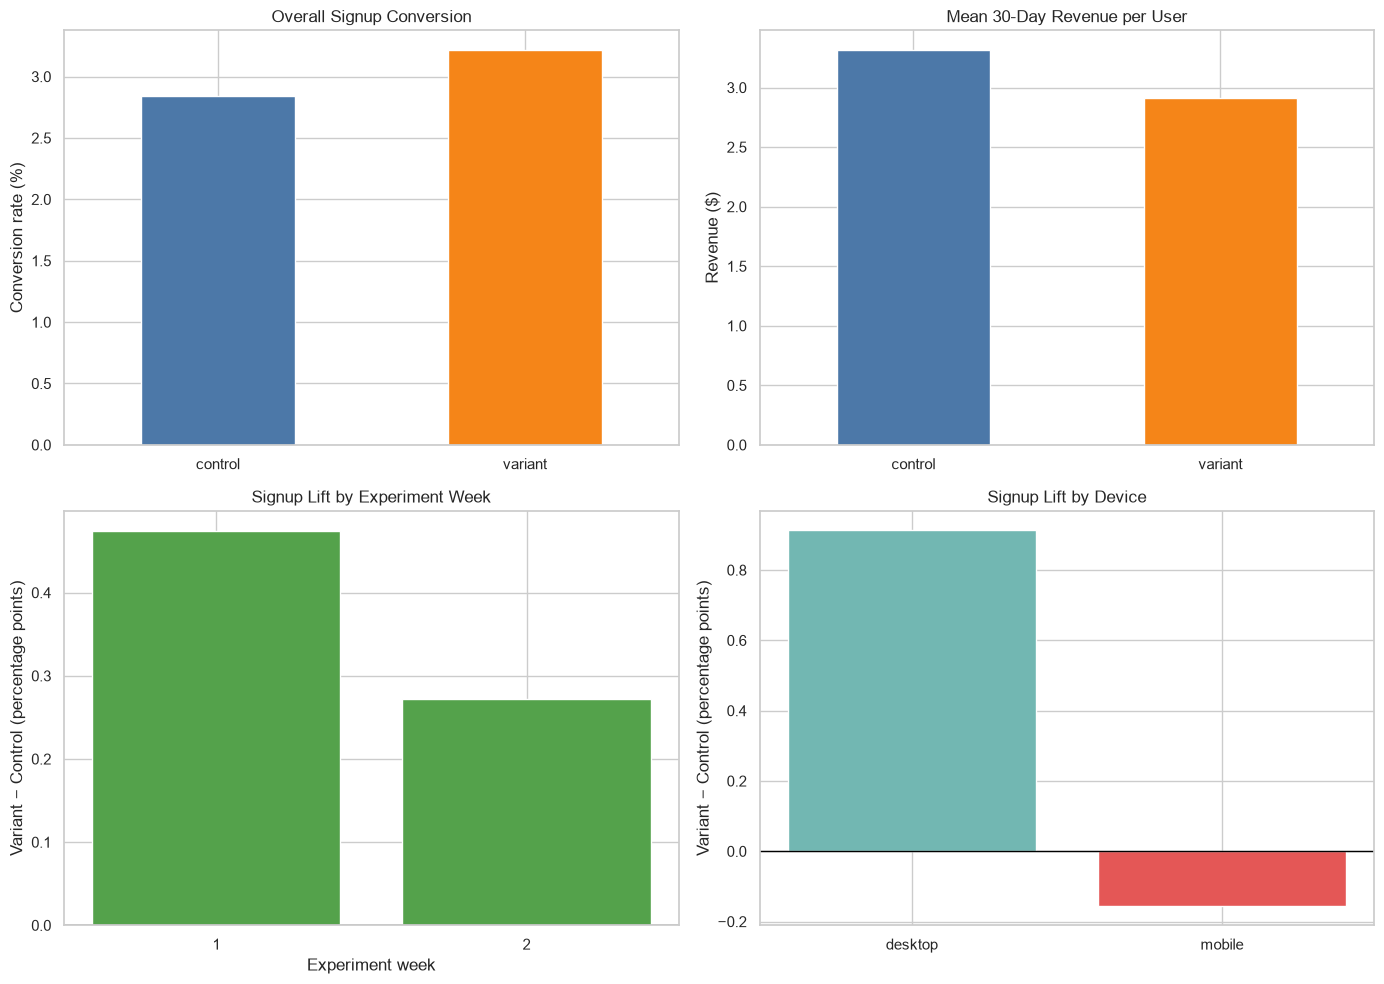

✅ Chart saved: d:\desktop\coding\Topfolio\A-B-Testing-Product-Experimentation-Analysis-M1\findings\figures\m4_experiment_diagnostics.png


In [13]:
# Milestone 4 diagnostic visualizations

figures_dir = project_root / "findings" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Overall signup conversion
(signup_summary["conversion_rate"] * 100).plot(
    kind="bar",
    ax=axes[0, 0],
    color=["#4C78A8", "#F58518"]
)

axes[0, 0].set_title("Overall Signup Conversion")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Conversion rate (%)")
axes[0, 0].tick_params(axis="x", rotation=0)

# 2. Mean 30-day revenue
revenue_summary["mean"].plot(
    kind="bar",
    ax=axes[0, 1],
    color=["#4C78A8", "#F58518"]
)

axes[0, 1].set_title("Mean 30-Day Revenue per User")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Revenue ($)")
axes[0, 1].tick_params(axis="x", rotation=0)

# 3. Week 1 versus Week 2 signup lift
axes[1, 0].bar(
    weekly_results["week"].astype(str),
    weekly_results["absolute_lift"] * 100,
    color="#54A24B"
)

axes[1, 0].axhline(0, color="black", linewidth=1)
axes[1, 0].set_title("Signup Lift by Experiment Week")
axes[1, 0].set_xlabel("Experiment week")
axes[1, 0].set_ylabel("Variant − Control (percentage points)")

# 4. Desktop versus mobile signup lift
axes[1, 1].bar(
    segment_results.index,
    segment_results["absolute_lift"] * 100,
    color=["#72B7B2", "#E45756"]
)

axes[1, 1].axhline(0, color="black", linewidth=1)
axes[1, 1].set_title("Signup Lift by Device")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Variant − Control (percentage points)")

plt.tight_layout()

chart_path = figures_dir / "m4_experiment_diagnostics.png"
plt.savefig(chart_path, dpi=300, bbox_inches="tight")
plt.show()

print(f"✅ Chart saved: {chart_path}")

In [14]:
# Final Milestone 4 validation

report_path = project_root / "findings" / "04_experiment_diagnostics.md"
figure_path = (
    project_root
    / "findings"
    / "figures"
    / "m4_experiment_diagnostics.png"
)
notebook_path = (
    project_root
    / "notebooks"
    / "04_ab_test_evaluation.ipynb"
)

# Data-quality validation
assert len(experiment) == 50_000
assert experiment["user_id"].nunique() == 50_000
assert experiment.duplicated().sum() == 0
assert experiment.isna().sum().sum() == 0
assert experiment["signup_completed"].isin([0, 1]).all()
assert (experiment["revenue_30d"] >= 0).all()

arm_counts_check = experiment["arm"].value_counts()
assert arm_counts_check["control"] == 25_053
assert arm_counts_check["variant"] == 24_947

# SRM validation
srm_check = chisquare(
    arm_counts_check.reindex(["control", "variant"]).values,
    f_exp=[25_000, 25_000]
)
assert srm_check.pvalue > 0.05

# Primary conversion validation
validation_signup = (
    experiment.groupby("arm")
    .agg(
        users=("user_id", "nunique"),
        signups=("signup_completed", "sum")
    )
)

validation_signup["rate"] = (
    validation_signup["signups"] / validation_signup["users"]
)

primary_z, primary_p = proportions_ztest(
    validation_signup.loc[["variant", "control"], "signups"].values,
    validation_signup.loc[["variant", "control"], "users"].values
)

assert validation_signup.loc["variant", "rate"] > validation_signup.loc["control", "rate"]
assert primary_p < 0.05

# Revenue guardrail validation
control_revenue_check = experiment.loc[
    experiment["arm"] == "control", "revenue_30d"
]
variant_revenue_check = experiment.loc[
    experiment["arm"] == "variant", "revenue_30d"
]

revenue_t, revenue_p_check = ttest_ind(
    variant_revenue_check,
    control_revenue_check,
    equal_var=False
)

assert variant_revenue_check.mean() < control_revenue_check.mean()
assert revenue_p_check < 0.05

# Deliverable validation
assert notebook_path.exists(), f"Missing: {notebook_path}"
assert report_path.exists(), f"Missing: {report_path}"
assert figure_path.exists(), f"Missing: {figure_path}"
assert figure_path.stat().st_size > 0

report_text = report_path.read_text(encoding="utf-8")
report_word_count = len(report_text.split())

assert report_word_count >= 300
assert "Do not launch" in report_text
assert "Sample Ratio Mismatch" in report_text
assert "Welch" in report_text
assert "Device Analysis" in report_text

print("✅ Exactly 50,000 unique users validated")
print("✅ No duplicates or missing values")
print("✅ Expected control and variant counts validated")
print(f"✅ SRM passed: p = {srm_check.pvalue:.4f}")
print(f"✅ Signup Z-test validated: p = {primary_p:.4f}")
print(f"✅ Revenue guardrail failure validated: p = {revenue_p_check:.4f}")
print("✅ Notebook, report and visualization exist")
print(f"✅ Report word count: {report_word_count}")
print("✅ Milestone 4 validation passed")

✅ Exactly 50,000 unique users validated
✅ No duplicates or missing values
✅ Expected control and variant counts validated
✅ SRM passed: p = 0.6355
✅ Signup Z-test validated: p = 0.0150
✅ Revenue guardrail failure validated: p = 0.0323
✅ Notebook, report and visualization exist
✅ Report word count: 400
✅ Milestone 4 validation passed
